# Price prediction of cars based on SnapSoft preprocessed sample data using machine learning models
Since the company wants to sell its current inventory as
soon as possible, the preferred model slightly underestimates the price.


### Install and import necessary libraries

In [214]:
%pip install pandas numpy plotly scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [215]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline

np.random.seed(42)

## Loading data

In [216]:
df = pd.read_csv('../../ml_sample_data_snapsoft_preprocessed.csv')
print(df.shape)
df.head()

(235, 20)


,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,color,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
0,diesel,std,four,hatchback,fwd,front,95.7,yellow,166.3,64.4,52.8,2275,4.0,110,22.5,56.0,4500,38,47,7788.0
1,gas,std,four,wagon,4wd,front,95.7,purple,169.7,63.6,59.1,3110,4.0,92,9.0,62.0,4800,27,32,8778.0
2,gas,std,two,hatchback,rwd,front,98.4,navy,176.2,65.6,52.0,2714,4.0,146,9.3,116.0,4800,24,30,11549.0
3,gas,std,two,hatchback,rwd,front,102.9,fuchsia,183.5,67.7,52.0,3016,6.0,171,9.3,161.0,5200,19,24,15998.0
4,gas,std,four,sedan,fwd,front,100.4,yellow,184.6,66.5,55.1,3060,6.0,181,9.0,152.0,5200,19,25,13499.0


In [217]:
# Deduplication
before = len(df)
df = df.drop_duplicates()
print(f'Deduplication: removed {before - len(df)} duplicate rows. Remaining: {len(df)}')

Deduplication: removed 0 duplicate rows. Remaining: 235


In [218]:
df.dtypes

fueltype                str
aspiration              str
doornumber              str
carbody                 str
drivewheel              str
enginelocation          str
wheelbase           float64
color                   str
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
cylindernumber      float64
enginesize            int64
compressionratio    float64
horsepower          float64
peakrpm               int64
citympg               int64
highwaympg            int64
Price               float64
dtype: object

## Experimental data analysis

In [219]:
df.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
count,235.000000,231.000000,235.000000,235.000000,235.000000,227.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,98.576596,173.641558,65.840851,53.639574,2543.331915,4.361233,126.059574,10.180979,103.157447,5115.744681,25.370213,30.957447,13041.870923
std,5.883296,12.063445,2.090769,2.430998,509.763445,1.044113,40.195844,4.056151,38.420034,470.732039,6.506667,6.842419,7757.915869
min,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.050000,51.600000,2145.000000,4.000000,98.000000,8.500000,70.000000,4800.000000,19.500000,25.000000,7775.000000
50%,96.500000,173.000000,65.400000,54.100000,2405.000000,4.000000,119.000000,9.000000,95.000000,5100.000000,24.000000,30.000000,9995.000000
75%,101.200000,180.250000,66.500000,55.500000,2921.000000,4.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,35.000000,16501.500000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [220]:
df.isna().sum()

fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      9
wheelbase           0
color               0
carlength           4
carwidth            0
carheight           0
curbweight          0
cylindernumber      8
enginesize          0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
Price               0
dtype: int64

### Filling in missing values

In [221]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Categorical: fill with mode; numerical: fill with median
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == object or df[col].dtype == 'string':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print('\nMissing values after imputation:', df.isnull().sum().sum())

Missing values per column:
enginelocation    9
carlength         4
cylindernumber    8
dtype: int64

Missing values after imputation: 0


### Encoding Categorical Variables

In [222]:
df_encoded = df.copy()

# One-hot encode nominal columns with multiple unordered categories
ohe_cols = ['fueltype', 'carbody', 'drivewheel']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

# Label-encode the remaining categorical columns
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print('One-hot encoded:', ohe_cols)
print('Label encoded:', cat_cols)
print('Total features:', df_encoded.shape[1])

One-hot encoded: ['fueltype', 'carbody', 'drivewheel']
Label encoded: ['aspiration', 'doornumber', 'enginelocation', 'color']
Total features: 24


C:\Users\tamas\AppData\Local\Temp\ipykernel_24592\4080585892.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()


## Correlation Analysis

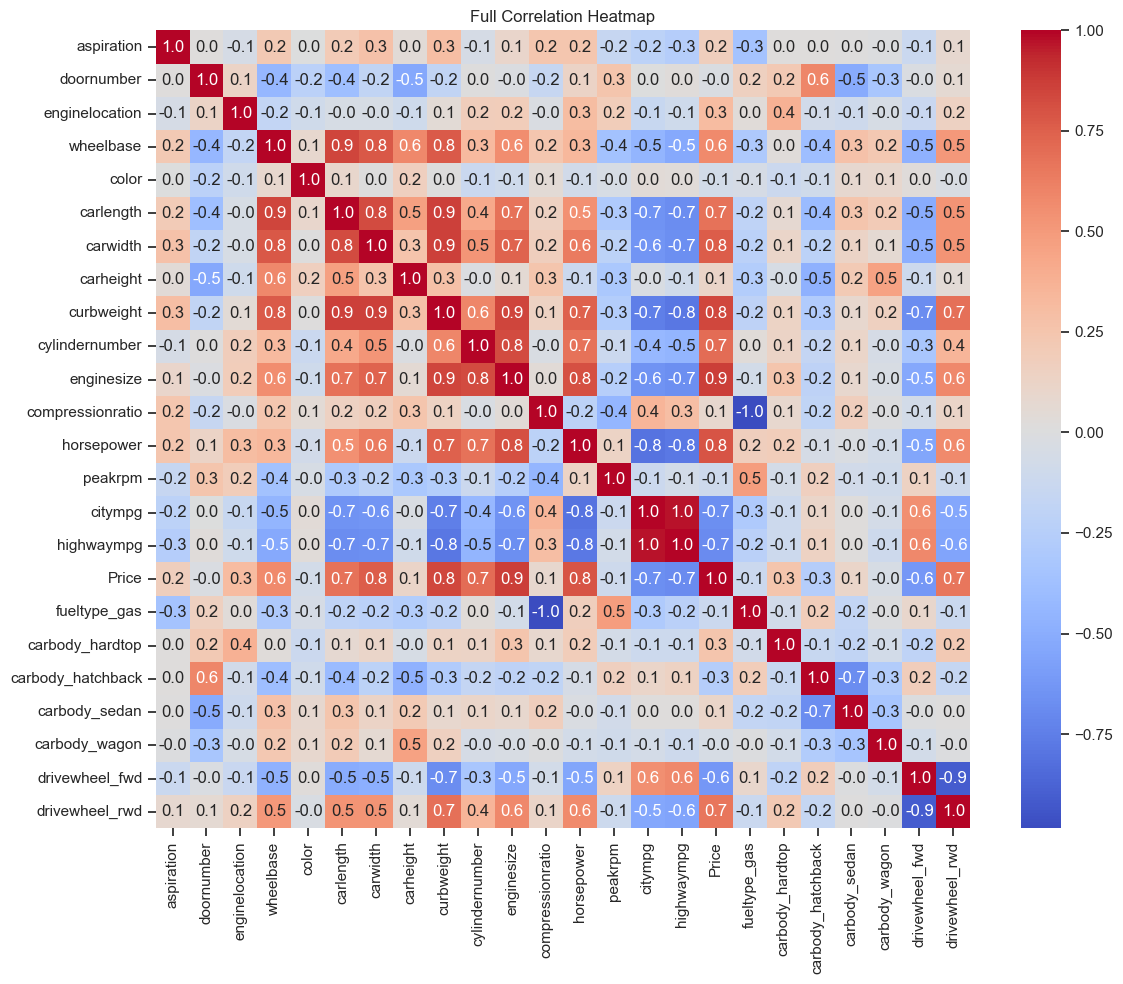

In [223]:
full_corr = df_encoded.corr()
corr = full_corr['Price'].drop('Price')

plt.figure(figsize=(12, 10))
sns.heatmap(full_corr, annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Full Correlation Heatmap')
plt.tight_layout()
plt.show()

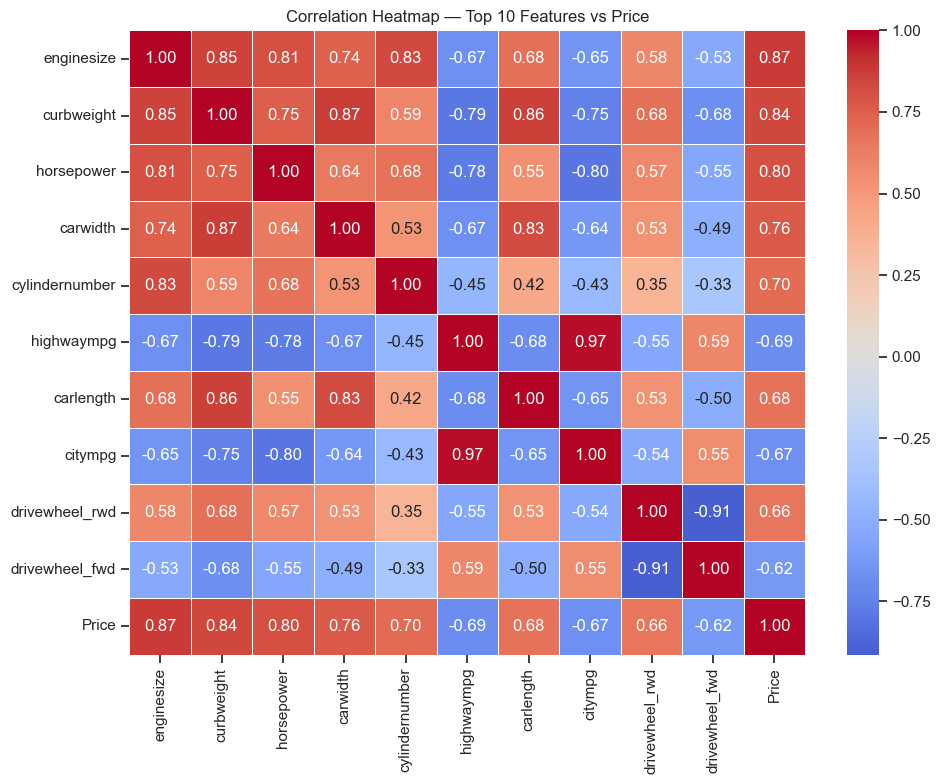

In [224]:
top_features = corr.abs().nlargest(10).index.tolist() + ['Price']

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_encoded[top_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5
)
plt.title('Correlation Heatmap — Top 10 Features vs Price')
plt.tight_layout()
plt.show()

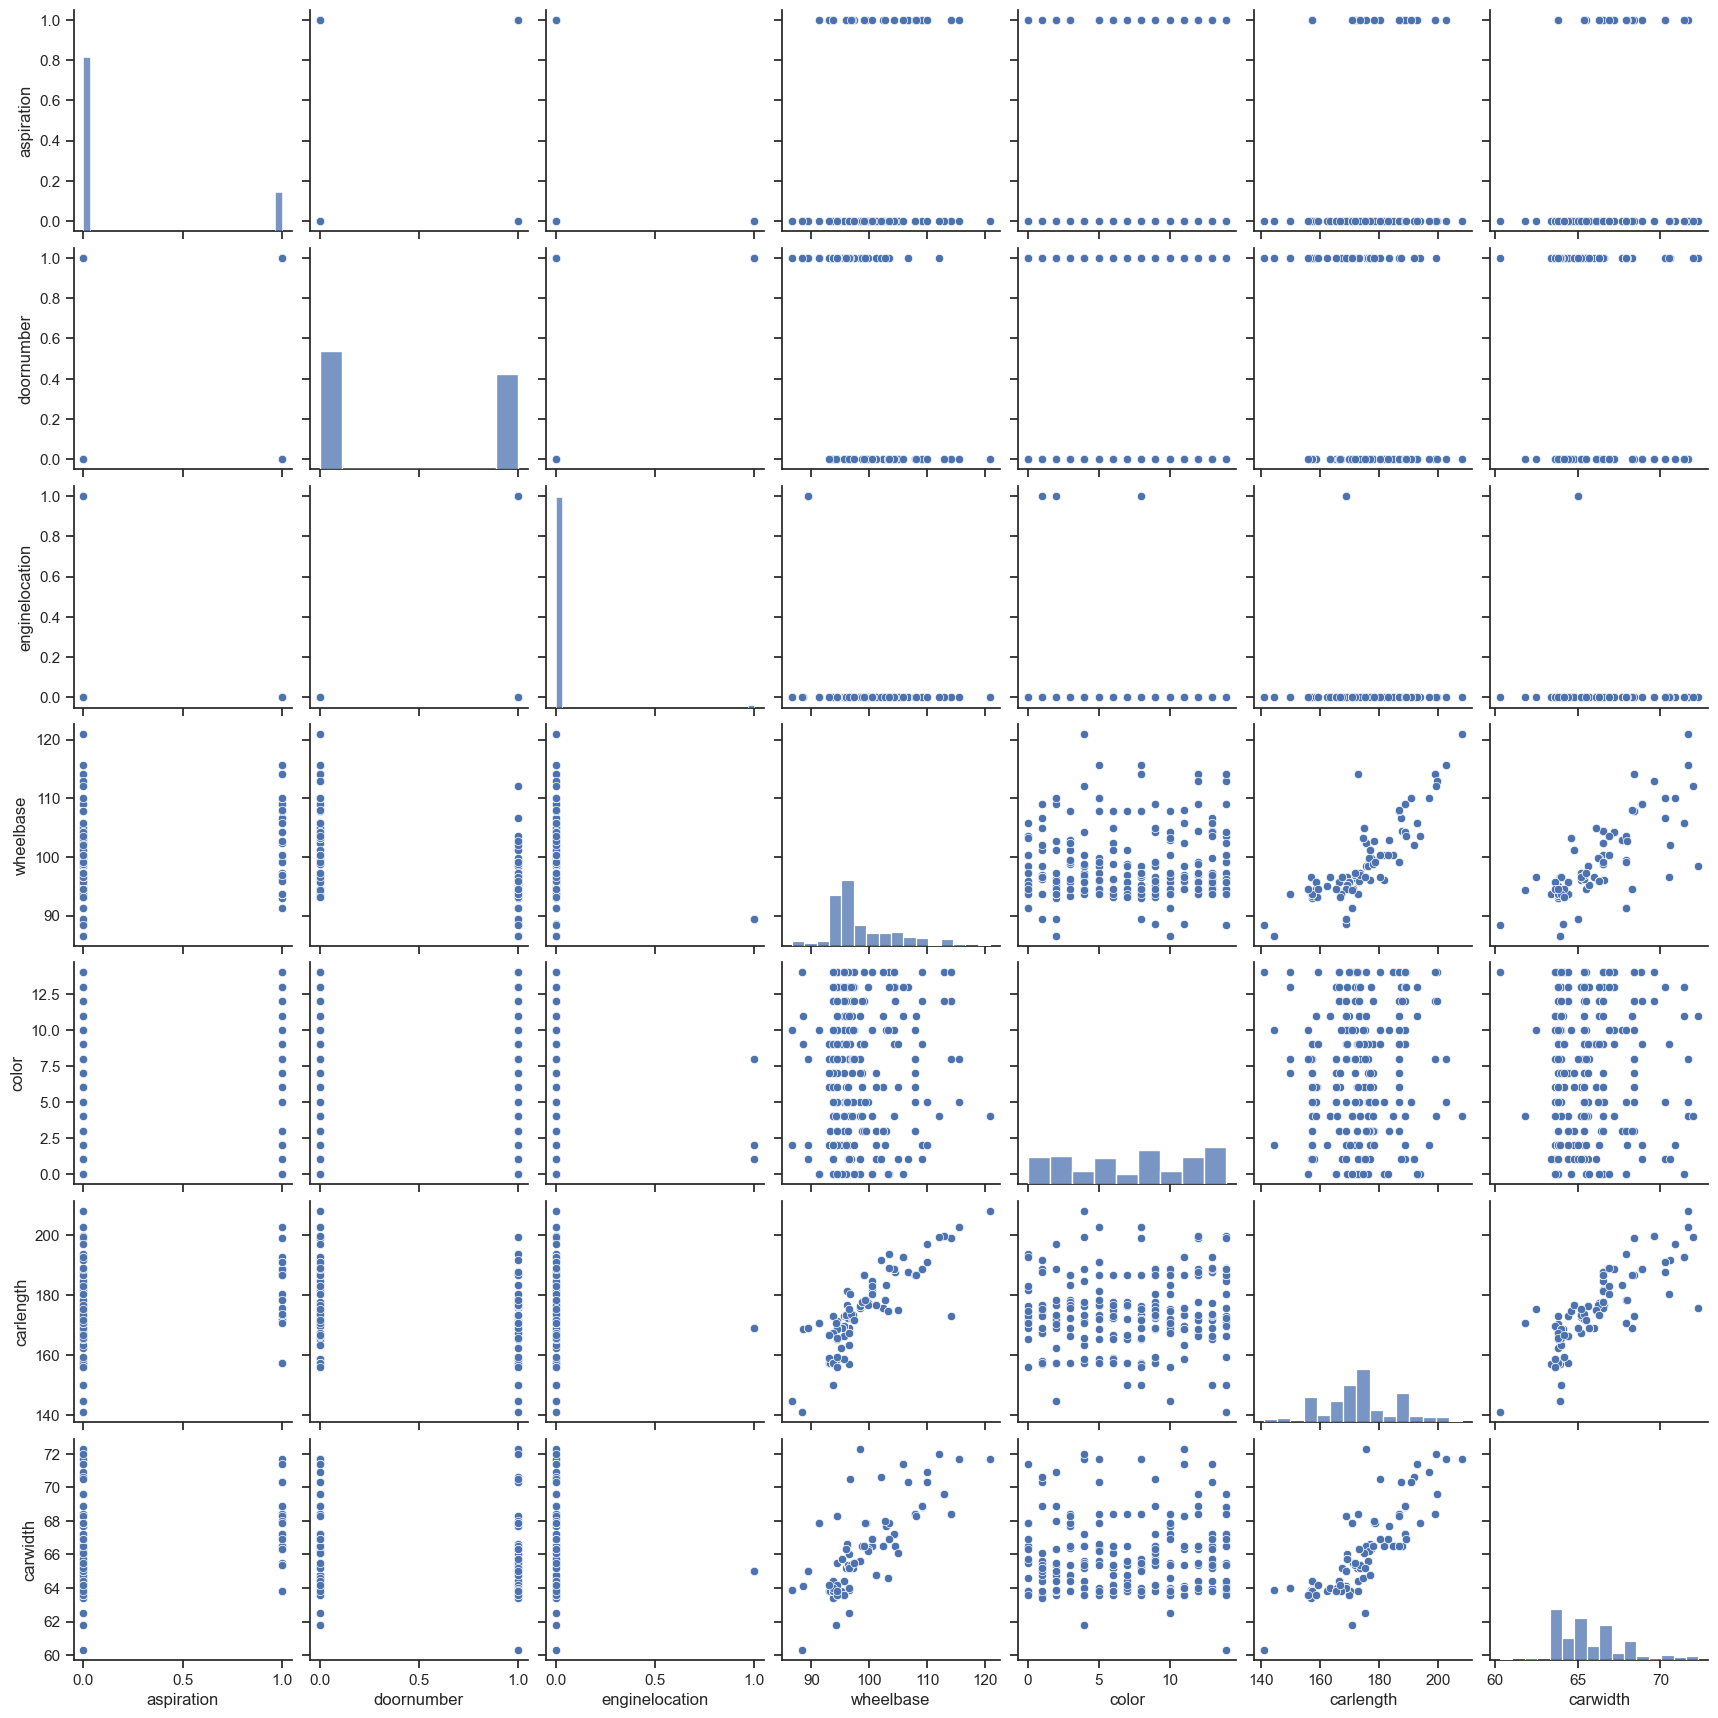

In [225]:
sns.set(style="ticks", color_codes=True)
g = sns.pairplot(df_encoded.iloc[:, :7])
plt.show()

## Train Test Split and Scaling

In [226]:
# Split data into 3 parts: training 80%, validation 10%, test 10%
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_trainvalid, X_test, y_trainvalid, y_test = train_test_split(
    X, y, test_size=0.1, shuffle=True, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainvalid, y_trainvalid, test_size=1/9, shuffle=True, random_state=42
)

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(187, 23)
(24, 23)
(24, 23)


In [227]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)
print('Features scaled.')

Features scaled.


## Model Training

### Linear Regression model

In [228]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print('Linear Regression trained successfully.')

Linear Regression trained successfully.


### Random Forest model

In [229]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
print('Random Forest trained successfully.')

Random Forest trained successfully.


### Gradient Boosting model

In [230]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_scaled, y_train)
print('Gradient Boosting trained successfully.')

Gradient Boosting trained successfully.


## Model Evaluation

In [231]:
def print_metrics(name, y_true_val, y_pred_val, y_true_test, y_pred_test):
    print(f'=== {name} ===')
    print(f'  Validation  — MAE: {mean_absolute_error(y_true_val, y_pred_val):.2f} | '
          f'RMSE: {np.sqrt(mean_squared_error(y_true_val, y_pred_val)):.2f} | '
          f'R²: {r2_score(y_true_val, y_pred_val):.4f}')
    print(f'  Test        — MAE: {mean_absolute_error(y_true_test, y_pred_test):.2f} | '
          f'RMSE: {np.sqrt(mean_squared_error(y_true_test, y_pred_test)):.2f} | '
          f'R²: {r2_score(y_true_test, y_pred_test):.4f}')

lr_valid_pred = lr_model.predict(X_valid_scaled)
lr_test_pred  = lr_model.predict(X_test_scaled)
rf_valid_pred = rf_model.predict(X_valid_scaled)
rf_test_pred  = rf_model.predict(X_test_scaled)
gb_valid_pred = gb_model.predict(X_valid_scaled)
gb_test_pred  = gb_model.predict(X_test_scaled)

print_metrics('Linear Regression',  y_valid, lr_valid_pred, y_test, lr_test_pred)
print()
print_metrics('Random Forest',  y_valid, rf_valid_pred, y_test, rf_test_pred)
print()
print_metrics('Gradient Boosting',  y_valid, gb_valid_pred, y_test, gb_test_pred)

=== Linear Regression ===
  Validation  — MAE: 1945.72 | RMSE: 2651.34 | R²: 0.8331
  Test        — MAE: 2756.27 | RMSE: 4399.42 | R²: 0.7747

=== Random Forest ===
  Validation  — MAE: 1128.67 | RMSE: 1545.50 | R²: 0.9433
  Test        — MAE: 1500.57 | RMSE: 2311.92 | R²: 0.9378

=== Gradient Boosting ===
  Validation  — MAE: 1048.84 | RMSE: 1443.16 | R²: 0.9506
  Test        — MAE: 1798.70 | RMSE: 2461.36 | R²: 0.9295


## Best Model Selection 

In [232]:

candidates = {
    'Linear Regression':  (lr_model, lr_valid_pred),
    'Random Forest':      (rf_model, rf_valid_pred),
    'Gradient Boosting':  (gb_model, gb_valid_pred),
}

test_mse = {name: mean_squared_error(y_valid, preds) for name, (_, preds) in candidates.items()}
test_mae = {name: mean_absolute_error(y_valid, preds) for name, (_, preds) in candidates.items()}

print('Test MSE scores:')
for name, score in test_mse.items():
    marker = '  < BEST' if name == min(test_mse, key=test_mse.get) else ''
    print(f'  {name}: {score:.2f}{marker}')

best_name = min(test_mse, key=test_mse.get)
best_model, best_test_pred = candidates[best_name]
print(f'\nBest model based on Test MSE: {best_name}')

print('\nTest MAE scores:')
for name, score in test_mae.items():
    marker = '  < BEST' if name == min(test_mae, key=test_mae.get) else ''
    print(f'  {name}: {score:.2f}{marker}')

best_name = min(test_mae, key=test_mae.get)
best_model, best_test_pred = candidates[best_name]
print(f'\nBest model based on Test MAE: {best_name}')


Test MSE scores:
  Linear Regression: 7029610.19
  Random Forest: 2388556.61
  Gradient Boosting: 2082711.23  < BEST

Best model based on Test MSE: Gradient Boosting

Test MAE scores:
  Linear Regression: 1945.72
  Random Forest: 1128.67
  Gradient Boosting: 1048.84  < BEST

Best model based on Test MAE: Gradient Boosting


### Based on MAE and MSE the best model is Gradient Boosting

## Checking which models estimations

In [233]:
avg_lr_error = np.mean( lr_test_pred-y_test)
avg_rf_error = np.mean(rf_test_pred-y_test)
avg_gb_error = np.mean(gb_test_pred-y_test)  

print(f'Average error (y_test - y_pred):')
print(f'  Linear Regression: {avg_lr_error:.2f}')   
print(f'  Random Forest: {avg_rf_error:.2f}')   
print(f'  Gradient Boosting: {avg_gb_error:.2f}')   



Average error (y_test - y_pred):
  Linear Regression: -789.80
  Random Forest: 432.64
  Gradient Boosting: 959.99


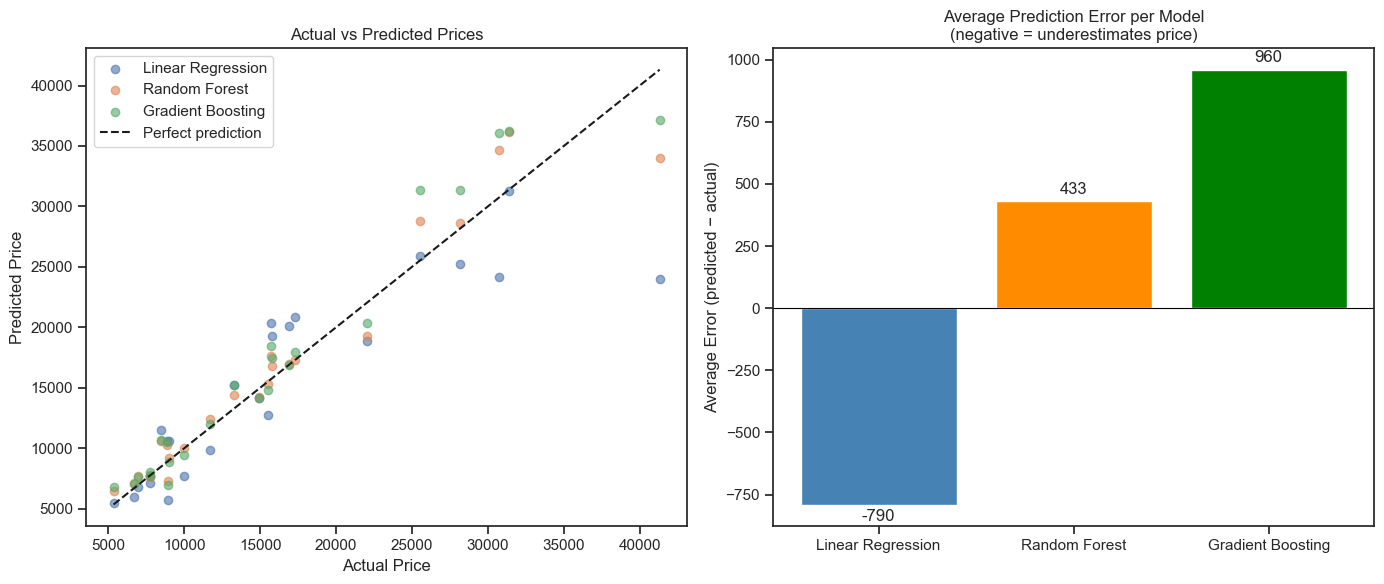

In [234]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: actual vs predicted prices
axes[0].scatter(y_test, lr_test_pred, alpha=0.6, label='Linear Regression')
axes[0].scatter(y_test, rf_test_pred, alpha=0.6, label='Random Forest')
axes[0].scatter(y_test, gb_test_pred, alpha=0.6, label='Gradient Boosting')
min_val = y_test.min()
max_val = y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].legend()

# Bar chart: average error per model (negative = underestimates, positive = overestimates)
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
avg_errors = [avg_lr_error, avg_rf_error, avg_gb_error]
bars = axes[1].bar(model_names, avg_errors, color=['steelblue', 'darkorange', 'green'])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Average Error (predicted − actual)')
axes[1].set_title('Average Prediction Error per Model\n(negative = underestimates price)')
axes[1].bar_label(bars, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

### Best model is Gradient boosting regressior, while Linear Regression is the only which underestimates the price.

## Gradient boosting regressor fine tuning to underestimate slightly the predicted price

In [235]:
gb_model2 = GradientBoostingRegressor(loss='quantile', alpha=0.46, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model2.fit(X_train_scaled, y_train)
print('Gradient Boosting trained successfully.')

Gradient Boosting trained successfully.


In [236]:
gb_valid_pred2 = gb_model2.predict(X_valid_scaled)
gb_test_pred2  = gb_model2.predict(X_test_scaled)

In [237]:
# Full evaluation of the final model on both validation and test sets
print('=== Quantile Gradient Boosting (alpha=0.46) ===')
for split, y_true, y_pred in [('Validation', y_valid, gb_valid_pred2), ('Test', y_test, gb_test_pred2)]:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    avg_err = np.mean(y_pred - y_true)
    direction = 'underestimates' if avg_err < 0 else 'overestimates'
    print(f'  {split:<12} — MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f} | '
          f'Avg error: {avg_err:.2f} ({direction})')

=== Quantile Gradient Boosting (alpha=0.46) ===
  Validation   — MAE: 1747.95 | RMSE: 2701.43 | R²: 0.8268 | Avg error: -450.65 (underestimates)
  Test         — MAE: 1530.78 | RMSE: 2268.39 | R²: 0.9401 | Avg error: -44.03 (underestimates)


In [238]:
avg_gb_error = np.mean(gb_test_pred2-y_test)  
print(f'  Gradient Boosting: {avg_gb_error:.2f}') 

  Gradient Boosting: -44.03


### By tweaking the params (alfa and loss) of the model it slightly underestimates the predicted price